Problem statement: To build a CNN based model which can accurately detect melanoma. Melanoma is a type of cancer that can be deadly if not detected early. It accounts for 75% of skin cancer deaths. A solution which can evaluate images and alert the dermatologists about the presence of melanoma has the potential to reduce a lot of manual effort needed in diagnosis.

### Importing Skin Cancer Data
#### To do: Take necessary actions to read the data

### Importing all the important libraries

In [1]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from glob import glob
import seaborn as sns


INFO:tensorflow:Enabling eager execution
INFO:tensorflow:Enabling v2 tensorshape
INFO:tensorflow:Enabling resource variables
INFO:tensorflow:Enabling tensor equality
INFO:tensorflow:Enabling control flow v2


In [2]:
## If you are using the data by mounting the google drive, use the following :
## from google.colab import drive
## drive.mount('/content/gdrive')

##Ref:https://towardsdatascience.com/downloading-datasets-into-google-drive-via-google-colab-bcb1b30b0166

This assignment uses a dataset of about 2357 images of skin cancer types. The dataset contains 9 sub-directories in each train and test subdirectories. The 9 sub-directories contains the images of 9 skin cancer types respectively.

In [3]:
# Defining the path for train and test images
## Todo: Update the paths of the train and test dataset
data_dir_train = pathlib.Path(r"C:\Users\dharani\Documents\DS\CNN\Data\Train")
data_dir_test = pathlib.Path(r"C:\Users\dharani\Documents\DS\CNN\Data\Test")

In [4]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2239
118


In [5]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2239
118


### Load using keras.preprocessing

Let's load these images off disk using the helpful image_dataset_from_directory utility.

### Create a dataset

Define some parameters for the loader:

In [6]:
batch_size = 32
img_height = 180
img_width = 180

Use 80% of the images for training, and 20% for validation.

In [7]:
## Write your train dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.


In [8]:
## Write your validation dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2239 files belonging to 9 classes.
Using 447 files for validation.


In [9]:
# List out all the classes of skin cancer and store them in a list. 
# You can find the class names in the class_names attribute on these datasets. 
# These correspond to the directory names in alphabetical order.
class_names = train_ds.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


### Visualize the data
#### Todo, create a code to visualize one instance of all the nine classes present in the dataset

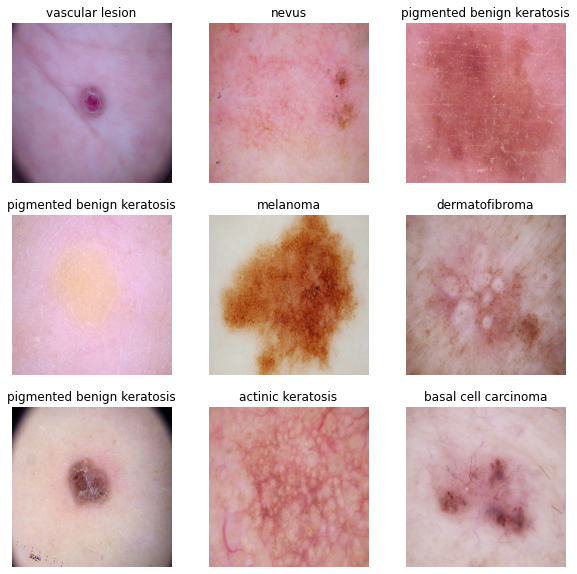

In [10]:
### your code goes here, you can use training or validation data to visualize
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

The `image_batch` is a tensor of the shape `(32, 180, 180, 3)`. This is a batch of 32 images of shape `180x180x3` (the last dimension refers to color channels RGB). The `label_batch` is a tensor of the shape `(32,)`, these are corresponding labels to the 32 images.

`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

`Dataset.prefetch()` overlaps data preprocessing and model execution while training.

In [11]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Create the model
#### Todo: Create a CNN model, which can accurately detect 9 classes present in the dataset. Use ```layers.experimental.preprocessing.Rescaling``` to normalize pixel values between (0,1). The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network. Here, it is good to standardize values to be in the `[0, 1]`

In [12]:
### Your code goes here
num_classes = 9

model = Sequential([
  layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

### Compile the model
Choose an appropirate optimiser and loss function for model training 

In [13]:
### Todo, choose an appropirate optimiser and loss function
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [14]:
# View the summary of all layers
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
rescaling (Rescaling)        (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 45, 45, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 45, 45, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 22, 22, 64)        0

### Train the model

In [15]:
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 [==============================] - 29s 438ms/step - loss: 2.0878 - accuracy: 0.2242 - val_loss: 1.7428 - val_accuracy: 0.3826
Epoch 2/20
56/56 [==============================] - 22s 397ms/step - loss: 1.6634 - accuracy: 0.4302 - val_loss: 1.5322 - val_accuracy: 0.4877
Epoch 3/20
56/56 [==============================] - 23s 403ms/step - loss: 1.4148 - accuracy: 0.5264 - val_loss: 1.4411 - val_accuracy: 0.5414
Epoch 4/20
56/56 [==============================] - 22s 397ms/step - loss: 1.2601 - accuracy: 0.5641 - val_loss: 1.4284 - val_accuracy: 0.5213
Epoch 5/20
56/56 [==============================] - 22s 396ms/step - loss: 1.2996 - accuracy: 0.5503 - val_loss: 1.4491 - val_accuracy: 0.5235
Epoch 6/20
56/56 [==============================] - 23s 404ms/step - loss: 1.1082 - accuracy: 0.5987 - val_loss: 1.4211 - val_accuracy: 0.5280
Epoch 7/20
56/56 [==============================] - 22s 391ms/step - loss: 1.0308 - accuracy: 0.6355 - val_loss: 1.4479 - val_accuracy: 0.5324

### Visualizing training results

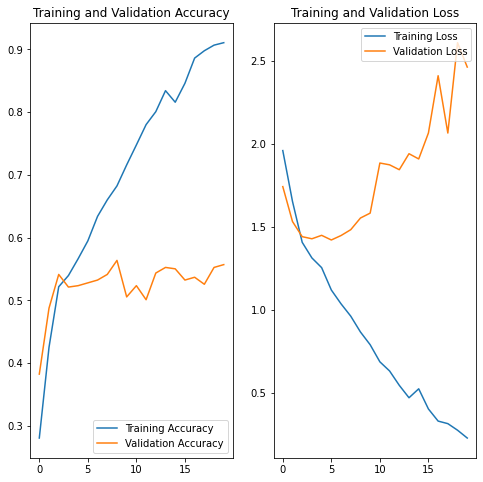

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Write your findings here

#### Todo: Write your findings after the model fit, see if there is an evidence of model overfit or underfit

As we can see from the plots, training accuracy and validation accuracy are off by large margin and the model has achieved only around 55% accuracy on the validation data set.
- Training accuracy : **91%**
- Validation accuracy : **55%**

Let's look at what went wrong and try to increase the overall performance of the model.


### Overfitting
- In the plots above, the training accuracy is increasing linearly over time, whereas validation accuracy stalls around 55% in the training process. Also, the difference in accuracy between training and validation accuracy is noticeable. It is a sign of **overfitting**.

- When there are a small number of training examples, the model sometimes learns from noises or unwanted details from training examples to an extent that it negatively impacts the performance of the model on new examples. This phenomenon is known as overfitting. It means that the model will have a difficult time generalizing on a new dataset.

- There are multiple ways to fight overfitting in the training process. Below we will be using data augmentation and adding Dropout layesr to overcome overfitting, let's analyse further.


In [17]:
# Todo, after you have analysed the model fit history for presence of underfit or overfit, choose an appropriate data augumentation strategy. 
# Your code goes here

In [18]:
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal", 
                                                 input_shape=(img_height, 
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

In [19]:
# Todo, visualize how your augmentation strategy works for one instance of training image.
# Your code goes here

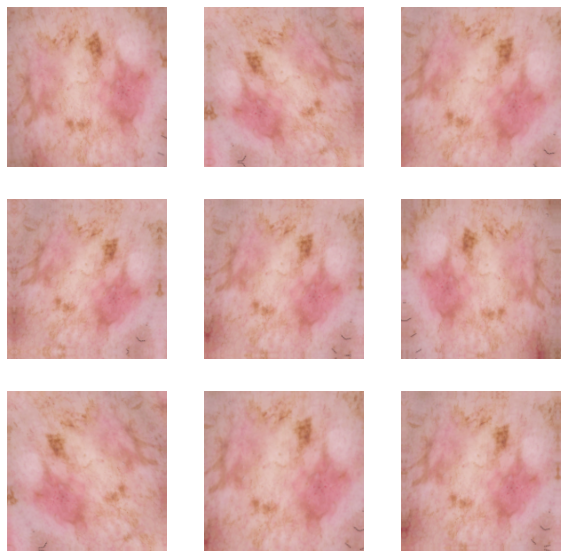

In [20]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

### Todo:
### Create the model, compile and train the model


In [21]:
## You can use Dropout layer if there is an evidence of overfitting in your findings

## Your code goes here

model = Sequential([
  data_augmentation,
  layers.experimental.preprocessing.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])


### Compiling the model

In [22]:
## Your code goes here
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_1 (Sequential)    (None, 180, 180, 3)       0         
_________________________________________________________________
rescaling_1 (Rescaling)      (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 45, 45, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 45, 45, 64)       

### Training the model

In [24]:
## Your code goes here, note: train your model for 20 epochs
#history = ## your training code
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 [==============================] - 25s 430ms/step - loss: 2.0796 - accuracy: 0.2358 - val_loss: 1.7634 - val_accuracy: 0.3579
Epoch 2/20
56/56 [==============================] - 25s 442ms/step - loss: 1.7097 - accuracy: 0.3714 - val_loss: 1.5349 - val_accuracy: 0.4944
Epoch 3/20
56/56 [==============================] - 24s 434ms/step - loss: 1.5858 - accuracy: 0.4156 - val_loss: 1.4824 - val_accuracy: 0.4743
Epoch 4/20
56/56 [==============================] - 24s 433ms/step - loss: 1.4819 - accuracy: 0.4771 - val_loss: 1.3768 - val_accuracy: 0.5369
Epoch 5/20
56/56 [==============================] - 25s 454ms/step - loss: 1.3796 - accuracy: 0.5256 - val_loss: 1.3821 - val_accuracy: 0.5190
Epoch 6/20
56/56 [==============================] - 25s 445ms/step - loss: 1.3391 - accuracy: 0.5178 - val_loss: 1.3631 - val_accuracy: 0.5481
Epoch 7/20
56/56 [==============================] - 25s 439ms/step - loss: 1.3783 - accuracy: 0.5101 - val_loss: 1.4159 - val_accuracy: 0.5324

### Visualizing the results

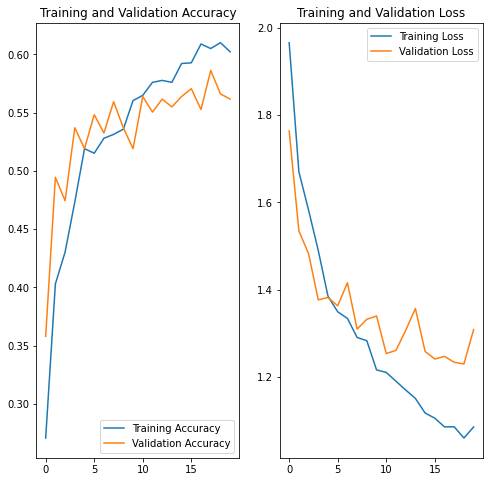

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Todo: Write your findings after the model fit, see if there is an evidence of model overfit or underfit. Do you think there is some improvement now as compared to the previous model run?

As we can see from the above plots, training accuracy and validation accuracy margin has been reduced compared to the first model. Approximate accuracy for the training and validation data sets is as below:

- Training accuracy : **62%**
- Validation accuracy : **56%**

The data agumentation and dropout layers helps here to reduce the overfit condition and build a generalized model. 


#### **Todo:** Find the distribution of classes in the training dataset.
#### **Context:** Many times real life datasets can have class imbalance, one class can have proportionately higher number of samples compared to the others. Class imbalance can have a detrimental effect on the final model quality. Hence as a sanity check it becomes important to check what is the distribution of classes in the data.

In [26]:
old_path_list = [x for x in glob(os.path.join(data_dir_train, '*','', '*.jpg'))]
old_path_list

['C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0025780.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0025803.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0025825.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0025953.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0025957.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0025992.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0026040.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0026149.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0026171.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\ISIC_0026194.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratos

In [27]:
lesion_list_old = [os.path.basename((os.path.dirname(y))) for y in glob(os.path.join(data_dir_train, '*','*.jpg'))]
lesion_list_old

['actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic 

In [28]:
dataframe_dict_old= dict(zip(old_path_list, lesion_list_old))
original_df = pd.DataFrame(list(dataframe_dict_old.items()),columns = ['Path','Label'])
original_df

,Path,Label
0,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
1,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
2,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
3,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
4,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
...,...,...
2234,C:\Users\dharani\Documents\DS\CNN\Data\Train\v...,vascular lesion
2235,C:\Users\dharani\Documents\DS\CNN\Data\Train\v...,vascular lesion
2236,C:\Users\dharani\Documents\DS\CNN\Data\Train\v...,vascular lesion
2237,C:\Users\dharani\Documents\DS\CNN\Data\Train\v...,vascular lesion


In [29]:
original_df['Label'].value_counts()

pigmented benign keratosis    462
melanoma                      438
basal cell carcinoma          376
nevus                         357
squamous cell carcinoma       181
vascular lesion               139
actinic keratosis             114
dermatofibroma                 95
seborrheic keratosis           77
Name: Label, dtype: int64

In [30]:
(original_df['Label'].value_counts()/2239)*100

pigmented benign keratosis    20.634212
melanoma                      19.562305
basal cell carcinoma          16.793211
nevus                         15.944618
squamous cell carcinoma        8.083966
vascular lesion                6.208129
actinic keratosis              5.091559
dermatofibroma                 4.242966
seborrheic keratosis           3.439035
Name: Label, dtype: float64

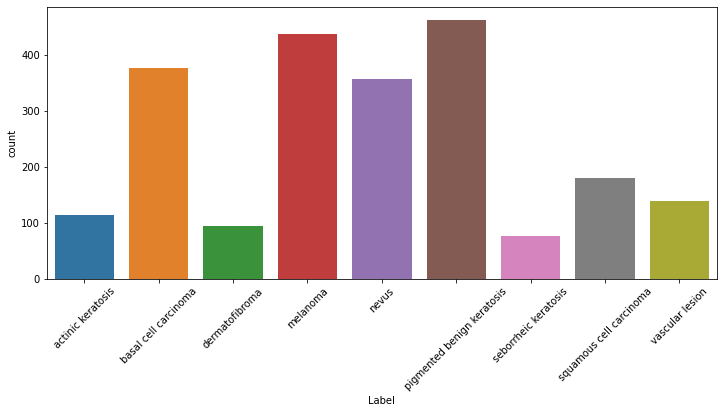

In [31]:
fig_dims = (12, 5)
fig, ax = plt.subplots(figsize=fig_dims)
ax = sns.countplot(x="Label", data=original_df)
locs, labels = plt.xticks()
plt.setp(labels, rotation=45)
plt.show()

#### **Todo:** Write your findings here: 
#### - Which class has the least number of samples?
The class **seborrheic keratosis** has least number of samples: **77**
#### - Which classes dominate the data in terms proportionate number of samples?
The dominant classes in the samples are as below: 
1. **pigmented benign keratosis**
2. **melanoma**
3. **basal cell carcinoma**
4. **nevus**

#### **Todo:** Rectify the class imbalance
#### **Context:** You can use a python package known as `Augmentor` (https://augmentor.readthedocs.io/en/master/) to add more samples across all classes so that none of the classes have very few samples.

In [32]:
!pip install Augmentor

To use `Augmentor`, the following general procedure is followed:

1. Instantiate a `Pipeline` object pointing to a directory containing your initial image data set.<br>
2. Define a number of operations to perform on this data set using your `Pipeline` object.<br>
3. Execute these operations by calling the `Pipeline’s` `sample()` method.


In [33]:

import Augmentor
for i in class_names:
    p = Augmentor.Pipeline(str(data_dir_train) + "\\" + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500) ## We are adding 500 samples per class to make sure that none of the classes are sparse.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x28496790B50>:   1%|          | 3/500 [00:00<00:11, 42.70 Samples/s]

Initialised with 114 image(s) found.
Output directory set to C:\Users\dharani\Documents\DS\CNN\Data\Train\actinic keratosis\output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x2849A50C0A0>: 100%|██████████| 500/500 [00:01<00:00, 260.43 Samples/s]                  
Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x2849A4E7E50>:   7%|▋         | 33/500 [00:00<00:15, 29.37 Samples/s]

Initialised with 376 image(s) found.
Output directory set to C:\Users\dharani\Documents\DS\CNN\Data\Train\basal cell carcinoma\output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x2849A5488B0>: 100%|██████████| 500/500 [00:02<00:00, 236.54 Samples/s]
Executing Pipeline:   0%|          | 0/500 [00:00<?, ? Samples/s]

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x2849662E490>: 100%|██████████| 500/500 [00:06<00:00, 82.57 Samples/s]                   
Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x2848FC93040>:   1%|          | 3/500 [00:00<00:59,  8.33 Samples/s]                  

Initialised with 181 image(s) found.
Output directory set to C:\Users\dharani\Documents\DS\CNN\Data\Train\squamous cell carcinoma\output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x28496712130>: 100%|██████████| 500/500 [00:02<00:00, 206.13 Samples/s]                  
Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x2848FCBCB50>:   3%|▎         | 14/500 [00:00<00:57,  8.40 Samples/s]                  

Initialised with 139 image(s) found.
Output directory set to C:\Users\dharani\Documents\DS\CNN\Data\Train\vascular lesion\output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x28496579DC0>: 100%|██████████| 500/500 [00:02<00:00, 218.64 Samples/s]                  


Augmentor has stored the augmented images in the output sub-directory of each of the sub-directories of skin cancer types.. Lets take a look at total count of augmented images.

In [34]:
data_dir_train

WindowsPath('C:/Users/dharani/Documents/DS/CNN/Data/Train')

In [35]:
image_count_train = len(list(data_dir_train.glob('*/output/*.jpg')))
print(image_count_train)

4500


### Lets see the distribution of augmented data after adding new images to the original training data.

In [36]:
from glob import glob

In [37]:
path_list = [x for x in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]
path_list

['C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025780.jpg_294fdcf2-2f9d-449e-a66e-04f764f095fb.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025780.jpg_d0ba0930-c277-4666-a161-62daba298e37.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025803.jpg_42cd5b78-dc01-4b51-bb79-69eeaccb088c.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025803.jpg_5ead538e-c42c-4df0-beef-44a946ebfac4.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025803.jpg_8c36773b-bd6f-4375-beda-cd09e8341b2f.jpg',
 'C:\\Users\\dharani\\Documents\\DS\\CNN\\Data\\Train\\actinic keratosis\\output\\actinic keratosis_original_ISIC_0025803.jpg_b1df3d82-3dfb-425d-9192-9cbce

In [38]:
lesion_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]
lesion_list_new

['actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic keratosis',
 'actinic 

In [39]:
dataframe_dict_new = dict(zip(path_list, lesion_list_new))

In [40]:
df2 = pd.DataFrame(list(dataframe_dict_new.items()),columns = ['Path','Label'])
#new_df = original_df.append(df2)
new_df = original_df.append(df2)

In [41]:
new_df['Label'].value_counts()

pigmented benign keratosis    962
melanoma                      938
basal cell carcinoma          876
nevus                         857
squamous cell carcinoma       681
vascular lesion               639
actinic keratosis             614
dermatofibroma                595
seborrheic keratosis          577
Name: Label, dtype: int64

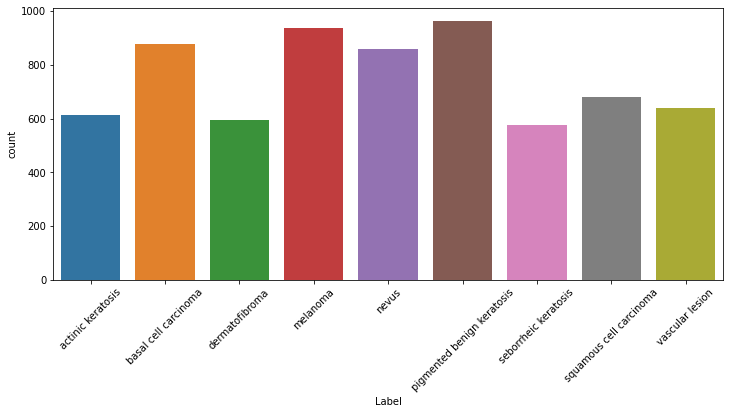

In [42]:
fig_dims = (12, 5)
fig, ax = plt.subplots(figsize=fig_dims)
ax = sns.countplot(x="Label", data=new_df)
locs, labels = plt.xticks()
plt.setp(labels, rotation=45)
plt.show()

In [43]:
new_df

,Path,Label
0,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
1,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
2,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
3,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
4,C:\Users\dharani\Documents\DS\CNN\Data\Train\a...,actinic keratosis
...,...,...
4495,C:\Users\dharani\Documents\DS\CNN\Data\Train\v...,vascular lesion
4496,C:\Users\dharani\Documents\DS\CNN\Data\Train\v...,vascular lesion
4497,C:\Users\dharani\Documents\DS\CNN\Data\Train\v...,vascular lesion
4498,C:\Users\dharani\Documents\DS\CNN\Data\Train\v...,vascular lesion


So, now we have added 500 images to all the classes to maintain some class balance. We can add more images as we want to improve training process.

#### **Todo**: Train the model on the data created using Augmentor

In [44]:
batch_size = 32
img_height = 180
img_width = 180

#### **Todo:** Create a training dataset

In [45]:
import shutil
import os

#rootdir = r'C:\Users\Pradeep Dharani\Documents\DS\DL\Asignment\New folder\Data\Train'

for cls in class_names:
   print(cls)
   source_dir = os.path.join(str(data_dir_train) + '\\'+cls, 'output')                
   target_dir = os.path.join(data_dir_train , cls)
   file_names = os.listdir(source_dir)
   for file_name in file_names:
       shutil.move(os.path.join(source_dir, file_name), target_dir)
    

actinic keratosis
basal cell carcinoma
dermatofibroma
melanoma
nevus
pigmented benign keratosis
seborrheic keratosis
squamous cell carcinoma
vascular lesion


In [46]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  seed=123,
  validation_split = 0.2,
  subset = "training",
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 5392 files for training.


#### **Todo:** Create a validation dataset

In [47]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  seed=123,
  validation_split = 0.2,
  subset = 'validation',
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 1347 files for validation.


#### **Todo:** Create your model (make sure to include normalization)

In [48]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
## your code goes here

In [49]:
normalization_layer = tf.keras.layers.experimental.preprocessing.Rescaling(1./255)

In [50]:
IMG_ROWS = 180
IMG_COLS = 180
NUM_CLASSES = 9
TEST_SIZE = 0.2
RANDOM_STATE = 2020
#Model
NO_EPOCHS = 30
BATCH_SIZE = 32

In [51]:
model = Sequential([
  data_augmentation,
  layers.experimental.preprocessing.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

#### **Todo:** Compile your model (Choose optimizer and loss function appropriately)

In [52]:
## your code goes here
model.compile(optimizer='adam',
              loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#### **Todo:**  Train your model

In [53]:
epochs = 50
## Your code goes here, use 50 epochs.
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/50


C:\Users\dharani\Anaconda3\envs\tensor\lib\site-packages\tensorflow\python\keras\backend.py:4929: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a sigmoid or softmax activation and thus does not represent logits. Was this intended?"
  warnings.warn(


169/169 [==============================] - 88s 469ms/step - loss: 2.2074 - accuracy: 0.1879 - val_loss: 1.6373 - val_accuracy: 0.4091
Epoch 2/50
169/169 [==============================] - 75s 443ms/step - loss: 1.5653 - accuracy: 0.4079 - val_loss: 1.4871 - val_accuracy: 0.4410
Epoch 3/50
169/169 [==============================] - 73s 434ms/step - loss: 1.4208 - accuracy: 0.4561 - val_loss: 1.3662 - val_accuracy: 0.5085
Epoch 4/50
169/169 [==============================] - 73s 435ms/step - loss: 1.2841 - accuracy: 0.5060 - val_loss: 1.2911 - val_accuracy: 0.5137
Epoch 5/50
169/169 [==============================] - 73s 430ms/step - loss: 1.2186 - accuracy: 0.5185 - val_loss: 1.2269 - val_accuracy: 0.5605
Epoch 6/50
169/169 [==============================] - 82s 488ms/step - loss: 1.2006 - accuracy: 0.5397 - val_loss: 1.1679 - val_accuracy: 0.5568
Epoch 7/50
169/169 [==============================] - 78s 464ms/step - loss: 1.1407 - accuracy: 0.5626 - val_loss: 1.2078 - val_accuracy: 0.5

#### **Todo:**  Visualize the model results

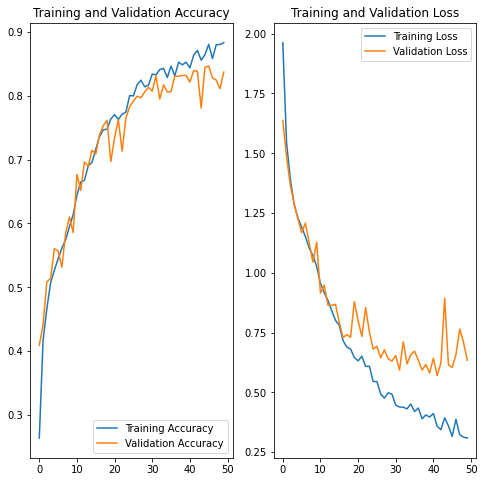

In [54]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### **Todo:**  Analyze your results here. Did you get rid of underfitting/overfitting? Did class rebalance help?



As we can see from the above plots, training accuracy and validation accuracy margin has been drastically reduced compared to the first and second models. 
The approximate accuracy achieved in the third model is as below:

- Training accuracy : **88%**
- Validation accuracy : **83%**

Reducing the class imbalance has helped here to get rid of overfitting in the model.

Finally, The data agumentation, dropout layers and reducing the class imbalance has helped build a generalized model. 